## Import Packages 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import os.path
import xesmf as xe
from scipy.signal import detrend
import statsmodels.api as sm

## Set up for Regridding Used in Code 

This is just setting up an empty xarray with space for latitude to run -90 degrees south to 90 degrees north, and longitude to run from 0 to 360 degrees going eastward

In [2]:
# Another method for out grid: 
ds_out = xr.Dataset({'lat': (['lat'], np.arange(-90, 90, 1.0)),
                     'lon': (['lon'], np.arange(0, 360, 1.0)),
                    }
                   )
ds_out

<xarray.Dataset> Size: 4kB
Dimensions:  (lat: 180, lon: 360)
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 86.0 87.0 88.0 89.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Data variables:
    *empty*

In [3]:
def get_path(model, variable, data_type, experiment_id, activity_id):
   
    import intake
    
    member_id_list = ["r1i1p1f1", "r1i1p1f2", "r1i1p1f2", "r1i1p2f1", "r4i1p1f1","r13i1p1f2"]
    grid_list = ["gr", "gn"] 
    
    url_cimp6 = '/glade/collections/cmip/catalog/intake-esm-datastore/catalogs/glade-cmip6.json'
    cat = intake.open_esm_datastore(url_cimp6)
    cat.df.head()
    
    selected_run = None
    selected_grid = None
    
    for run in member_id_list:
        cat_subset = cat.search(
            experiment_id=[experiment_id],
            table_id= data_type,
            variable_id= variable,
            source_id=model,
            member_id=run,
            activity_id = activity_id
        )
        
        if not cat_subset.df.empty:  # If we find a valid run, store it
            selected_run = run
            
            # Now try different grid labels
            for grid in grid_list:
                #print(f"Trying grid: {grid}")  
                cat_subset = cat.search(
                    experiment_id=[experiment_id],
                    table_id= data_type,
                    variable_id= variable,
                    source_id= model,
                    member_id=selected_run,
                    activity_id = activity_id,
                    grid_label=grid
                )
    
                if not cat_subset.df.empty:  # If we find a valid grid, store it and stop
                    selected_grid = grid
                    break  # Stop searching for grids
    
            break  # Stop searching for runs once we find a valid one
    
    #print(f"Selected run: {selected_run}, Selected grid: {selected_grid}")
    path = cat_subset.df["path"].tolist()
    return path

## Frontal Zones 

In [4]:
zones = {
    "siz": np.load('/glade/u/home/diegovar/teaching/Tutorials/Fronts/siz_grid.npy'),
    "az": np.load('/glade/u/home/diegovar/teaching/Tutorials/Fronts/az_grid.npy'),
    "saz": np.load('/glade/u/home/diegovar/teaching/Tutorials/Fronts/saz_grid.npy'),
    "stz": np.load('/glade/u/home/diegovar/teaching/Tutorials/Fronts/stz_grid.npy'),
    "pfz": np.load('/glade/u/home/diegovar/teaching/Tutorials/Fronts/pfz_grid.npy')
}

print("Loaded")

for key in zones:
    zones[key] = zones[key].astype(float)
    zones[key] = np.where(zones[key] == 0, np.nan, zones[key])

siz_zone = zones['siz']
az_zone = zones['az']
saz_zone = zones['saz']
stz_zone = zones['stz']
pfz_zone = zones['pfz']

Loaded


In [5]:
print(siz_zone.shape) 

(180, 360)


In [6]:
print(siz_zone.shape)
# masked_ds = ds.where(nmask) 
#boolian values -. True (1) or False (0) 
#SIZ ZONE MASK
mask_siz = np.isnan(np.flipud(siz_zone)) #sends nan values to True, non nans to False
#AZ ZONE MASK
mask_az = np.isnan(np.flipud(az_zone)) #sends nan values to True, non nans to False
#SAZ ZONE MASK
mask_saz = np.isnan(np.flipud(saz_zone)) #sends nan values to True, non nans to False
#STZ ZONE MASK
mask_stz = np.isnan(np.flipud(stz_zone)) #sends nan values to True, non nans to False
#PFZ ZONE MASK
mask_pfz = np.isnan(np.flipud(pfz_zone))  #sends nan values to True, non nans to False


zone_masks = {
    "siz": mask_siz,
    "az": mask_az,
    "saz": mask_saz,
    "stz": mask_stz,
    "pfz": mask_pfz
}

print(mask_pfz)

(180, 360)
[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]]


In [7]:
## Generate pCO2 Climatology

In [13]:
%%time
#timeseries
start_year = '1991'  # start year for data 
end_year = '2010'   # End year for data - this gives a 20 year time period 

models = ['CESM2']

variables = ["spco2"]

regions = ['siz', 'az', 'saz', 'stz', 'pfz']

for model in models:  # runs through every model in models list above
    # model will correspond to one of the models in the list above depeding on which loop iteration
    print(model) # prints model loop is on 
    
    #each model has a unique code that is part of its path (see paths above)  
 
    for var in variables: # for every model in model list we will go through ever variable in variables list
        print(var)
        path = get_path(model,var, "Omon", "historical","CMIP")
        #print(path)

        if not path:  
            print(model, var, "NO DATA")
            continue
        else:
            dataset = xr.open_mfdataset(path, chunks = None)  # opens dataset in xarray (see above) 
            dataset_in = dataset  # renames dataset to "dataset in" 
    
        for region in regions:  # loops over each southern ocean region 
            print(region)

            
            
            if isinstance(dataset_in, xr.Dataset): # this checks that the dataset sucessfully opened as an xarray 
    
                # this slices the dataset to the start and end year specified above and saves that to new variable ds 
                ds = dataset_in.sel(time=slice(start_year, end_year))[var]
    
                # the next 10 lines check for common names of coordinates in the data system and uniformly renames them 
                # then is selects the surface level for all datasets
                if 'latitude' in ds.coords: 
                     ds = ds.rename({'longitude': 'lon', 'latitude': 'lat'})
                if 'nav_lat' in ds.coords:
                     ds = ds.rename({'nav_lon': 'lon', 'nav_lat': 'lat'})
                if 'lev_partial' in ds.coords:
                     ds = ds.isel(lev_partial=0) #selects first value in depth feild (index of 1) 
                if 'olevel' in ds.coords:
                     ds = ds.isel(olevel=0) #selects first value in depth feild (index of 1) 
                if 'lev' in ds.coords:
                     ds = ds.isel(lev=0) #selects first value in depth feild (index of 1) 
                
                #discards any negative data for variable that should not have negative values 
                if var == 'phyc' or var == 'chl'  or var == 'no3' or var == 'si' or var == 'dfe' or var == 'dissic' or var == 'talk':
                    ds = ds.where(ds>=0)


                #Regiridding Data Here - puts all model data sets on same grid space
                # this is where we use the blank xarray created above
                ds_in = xr.Dataset({"lat": ds.lat, "lon": ds.lon})  # data going into regridding 
                dsr = xe.Regridder(ds_in, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
                dsr._grid_in = None
                dsr._grid_out = None
                dsr_out0 = dsr(ds)
                dsr_out = xr.Dataset({var:dsr_out0}) # regridded data set is spit out 
                
                # start of calculations for seasonal datasets 
                #print((dsr_out[var]).shape)
                if dsr_out[var].shape[0]==12*20:  #if the dataset has the desired number of months (12 months * number of years in your range) 
                
        #Calculations by region  
    
                    print('calculating')
                    
                    ds_np = (dsr_out).where(zone_masks[region] == False) 
               
                    # this section is detrending the data - do not worry about understanding this
                    dsm_np = ds_np[var].mean(dim='time',skipna=1) #averaging
                    anom_np = ds_np[var] - dsm_np
                    anom_np.load()
                    anom_detrended_np = xr.apply_ufunc(detrend, anom_np.fillna(0).chunk({"lon":45,"lat":45}), kwargs={'axis': 0},dask="parallelized", output_dtypes=[anom_np.dtype]).where(~anom_np.isnull())
                    detrend_np = anom_detrended_np + dsm_np
                    #print(detrend_np)
                    #detrending done 
            
                    # this line averages groups data by month, then takes the time mean, then the mean over all points in space 
                    #should leave you with a dataset of 12 points
                    do_np = detrend_np.groupby('time.month').mean('time',skipna=1).mean('lon',skipna=1).mean('lat',skipna=1).values
                
                    #print(do_np) # check you are getting 12 point datasets 
                    
                    #saves calculated dataset to indicated path
                    savef_path ='/glade/u/home/lilmi/2026ClimateBigData/testdata/' + model + '_' + var + start_year + end_year  + '_' + region + '.txt'  
                    with open(savef_path, 'w') as npf:
                        for idata in do_np:
                            npf.write(str(idata) +"\n") # writes data to a string file that can be read later 


CESM2
spco2


/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'spco2' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


siz
calculating
az
calculating
saz
calculating
stz
calculating
pfz
calculating
CPU times: user 1min 32s, sys: 5.84 s, total: 1min 38s
Wall time: 1min 1s


## Generate pCO2 Separation 

In [10]:
%%time
#timeseries
start_year = '1991'  # start year for data 
end_year = '2010'   # End year for data - this gives a 20 year time period 

models = ['CESM2'] # List of models to create climatologies for 

regions = ['siz', 'az', 'saz', 'stz', 'pfz']

for model in models:  # runs through every model in models list above
    # model will correspond to one of the models in the list above depeding on which loop iteration
    print(model) # prints model loop is on 
    
    #each model has a unique code that is part of its path (see paths above)  
    path_spco2 = get_path(model,'spco2', "Omon", "historical","CMIP")
    path_sst = get_path(model,'tos', "Omon", "historical","CMIP")

    if not path_spco2:  
        print(model, 'spco2', "NO DATA")
        continue
    if not path_sst:  
        print(model, 'tos', "NO DATA")
        continue
    
    else:
        dataset_spco2 = xr.open_mfdataset(path_spco2, chunks = None)  # opens dataset in xarray (see above) 
        dataset_in_spco2 = dataset_spco2  # renames dataset to "dataset in" 

        dataset_sst = xr.open_mfdataset(path_sst, chunks = None)  # opens dataset in xarray (see above) 
        dataset_in_sst = dataset_sst  # renames dataset to "dataset in"

    for region in regions:  # loops over each southern ocean region 
        print(region)
            
        if isinstance(dataset_in_spco2, xr.Dataset): # this checks that the dataset sucessfully opened as an xarray 

            # this slices the dataset to the start and end year specified above and saves that to new variable ds 
            ds_spco2 = dataset_in_spco2.sel(time=slice(start_year, end_year))['spco2']
            ds_sst = dataset_in_sst.sel(time=slice(start_year, end_year))['tos']
            print("bannanas") 
            # the next 10 lines check for common names of coordinates in the data system and uniformly renames them 
            # then is selects the surface level for all datasets
            if 'latitude' in ds_spco2.coords: 
                ds_spco2 = ds_spco2.rename({'longitude': 'lon', 'latitude': 'lat'})
            if 'latitude' in ds_sst.coords: 
                ds_sst = ds_sst.rename({'longitude': 'lon', 'latitude': 'lat'})
            if 'nav_lat' in ds_spco2.coords:
                ds_spco2 = ds_spco2.rename({'nav_lon': 'lon', 'nav_lat': 'lat'})
            if 'nav_lat' in ds_sst.coords:
                ds_sst = ds_sst.rename({'nav_lon': 'lon', 'nav_lat': 'lat'})
            if 'lev_partial' in ds_spco2.coords:
                ds_spco2 = ds_spco2.isel(lev_partial=0) #selects first value in depth feild (index of 1) 
            if 'lev_partial' in ds_sst.coords:
                ds_sst = ds_sst.isel(lev_partial=0) #selects first value in depth feild (index of 1) 
            if 'olevel' in ds_spco2.coords:
                ds_spco2 = ds_spco2.isel(olevel=0) #selects first value in depth feild (index of 1)
            if 'olevel' in ds_sst.coords:
                ds_sst = ds_sst.isel(olevel=0) #selects first value in depth feild (index of 1)
            if 'lev' in ds_spco2.coords:
                ds_spco2 = ds_spco2.isel(lev=0) #selects first value in depth feild (index of 1) 
            if 'lev' in ds_sst.coords:
                ds_sst = ds_sst.isel(lev=0) #selects first value in depth feild (index of 1) 
            
            print("polar bears") 
            
            #Regiridding spco2 data 
            # this is where we use the blank xarray created above
            ds_in_spco2 = xr.Dataset({"lat": ds_spco2.lat, "lon": ds_spco2.lon})  # data going into regridding 
            dsr_spco2 = xe.Regridder(ds_in_spco2, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
            dsr_spco2._grid_in = None
            dsr_spco2._grid_out = None
            dsr_out0_spco2 = dsr_spco2(ds_spco2)
            dsr_out_spco2 = xr.Dataset({'spco2':dsr_out0_spco2}) # regridded data set is spit out 

            #Regiridding sst data here
            # this is where we use the blank xarray created above
            ds_in_sst = xr.Dataset({"lat": ds_sst.lat, "lon": ds_sst.lon})  # data going into regridding 
            dsr_sst = xe.Regridder(ds_in_sst, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
            dsr_sst._grid_in = None
            dsr_sst._grid_out = None
            dsr_out0_sst = dsr_sst(ds_sst)
            dsr_out_sst = xr.Dataset({'tos':dsr_out0_sst}) # regridded data set is spit out 
            
            print("penguine")
            ds_spco2 = (dsr_out_spco2).where(zone_masks[region] == False) 
            ds_sst = (dsr_out_sst).where(zone_masks[region] == False)

            print("seals") 
            
            # this section is detrending the spco2 data 
            dsm_np = ds_spco2['spco2'].mean(dim='time',skipna=1) #averaging
            anom_np = ds_spco2['spco2'] - dsm_np
            anom_np.load()
            anom_detrended_np = xr.apply_ufunc(detrend, anom_np.fillna(0).chunk({"lon":45,"lat":45}), kwargs={'axis': 0},dask="parallelized", output_dtypes=[anom_np.dtype]).where(~anom_np.isnull())
            detrend_np = anom_detrended_np + dsm_np
            

            msp_np = ds_spco2['spco2'].mean(dim='time',skipna=1) # get mean of spco2 over time 
            anomsp_np = ds_spco2['spco2'] - msp_np
            
            mst_np = ds_sst['tos'].mean(dim='time',skipna=1)
            anomst_np = ds_sst['tos'] - mst_np
            
            anomsp_np.load()           
            anomsp_detrended_np = xr.apply_ufunc(detrend, anomsp_np.fillna(0), kwargs={'axis': 0}).where(~anomsp_np.isnull())
            dtsp_np = anomsp_detrended_np + msp_np   
            dtsp_np = dtsp_np / 0.101325 

            anomst_np.load()
            anomst_detrended_np = xr.apply_ufunc(detrend, anomst_np.fillna(0), kwargs={'axis': 0}).where(~anomst_np.isnull())
            dtst_np = anomst_detrended_np + mst_np      

            sp_temp_np = np.mean(dtsp_np) * np.exp(0.0423 * anomst_detrended_np)
            sp_ntemp_np = dtsp_np * np.exp( 0.0423 * (- anomst_detrended_np))       
            
            monsp_t_np = sp_temp_np.groupby('time.month').mean('time',skipna=1).mean('lon',skipna=1).mean('lat',skipna=1).values
            monsp_nt_np = sp_ntemp_np.groupby('time.month').mean('time',skipna=1).mean('lon',skipna=1).mean('lat',skipna=1).values
            sst_np = dtst_np.groupby('time.month').mean('time',skipna=1).mean('lon',skipna=1).mean('lat',skipna=1).values  

            print("ice creams") 
            savet_np = '/glade/u/home/lilmi/2026ClimateBigData/testdata/' + model + '_' + 'pco2-t'+ start_year + end_year  + '_' + region + '.txt'
            with open(savet_np, 'w') as nptf:
                for idata in monsp_t_np:
                    nptf.write(str(idata) +"\n")        
            
            savent_np = '/glade/u/home/lilmi/2026ClimateBigData/testdata/' + model + '_' + 'pco2-nt'+ start_year + end_year  + '_' + region + '.txt'
            with open(savent_np, 'w') as npntf:
                for idata in monsp_nt_np:
                    npntf.write(str(idata) +"\n")
            


CESM2


/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'spco2' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tos' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


siz
bannanas
polar bears
penguine
seals
ice creams
az
bannanas
polar bears
penguine
seals
ice creams
saz
bannanas
polar bears
penguine
seals
ice creams
stz
bannanas
polar bears
penguine
seals
ice creams
pfz
bannanas
polar bears
penguine
seals
ice creams
CPU times: user 4min 21s, sys: 9.23 s, total: 4min 30s
Wall time: 2min 43s


## Plotting

In [11]:
Time_months = ('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec')
# lables for months 
start_year=1991 #Start time for Data 
end_year=2010 # End time for Data 

#This is an array of RGB values to give each model (2) a unique color in the plot 
colors = [[255, 255, 38], [255, 182, 0], [255, 159, 0], 
          [204, 127, 0], [255, 2, 2], [255, 148, 255],
          [255, 6, 255], [127, 245, 206], [170, 211, 255], 
          [26, 136, 255], [175, 255, 175], [17, 137, 17], 
          [8, 8, 126], [130, 55, 6], [112, 48, 160],
          [184, 184, 255], [92, 92, 255], [4, 2, 0]]
newcolors = []
#this section just turns the colors list into decimal values that are readable by python 
for color in colors:
    newcolors.append([x/255.0 for x in color])

#colors is the array with the color values that you will call later 
colors=np.array(newcolors)


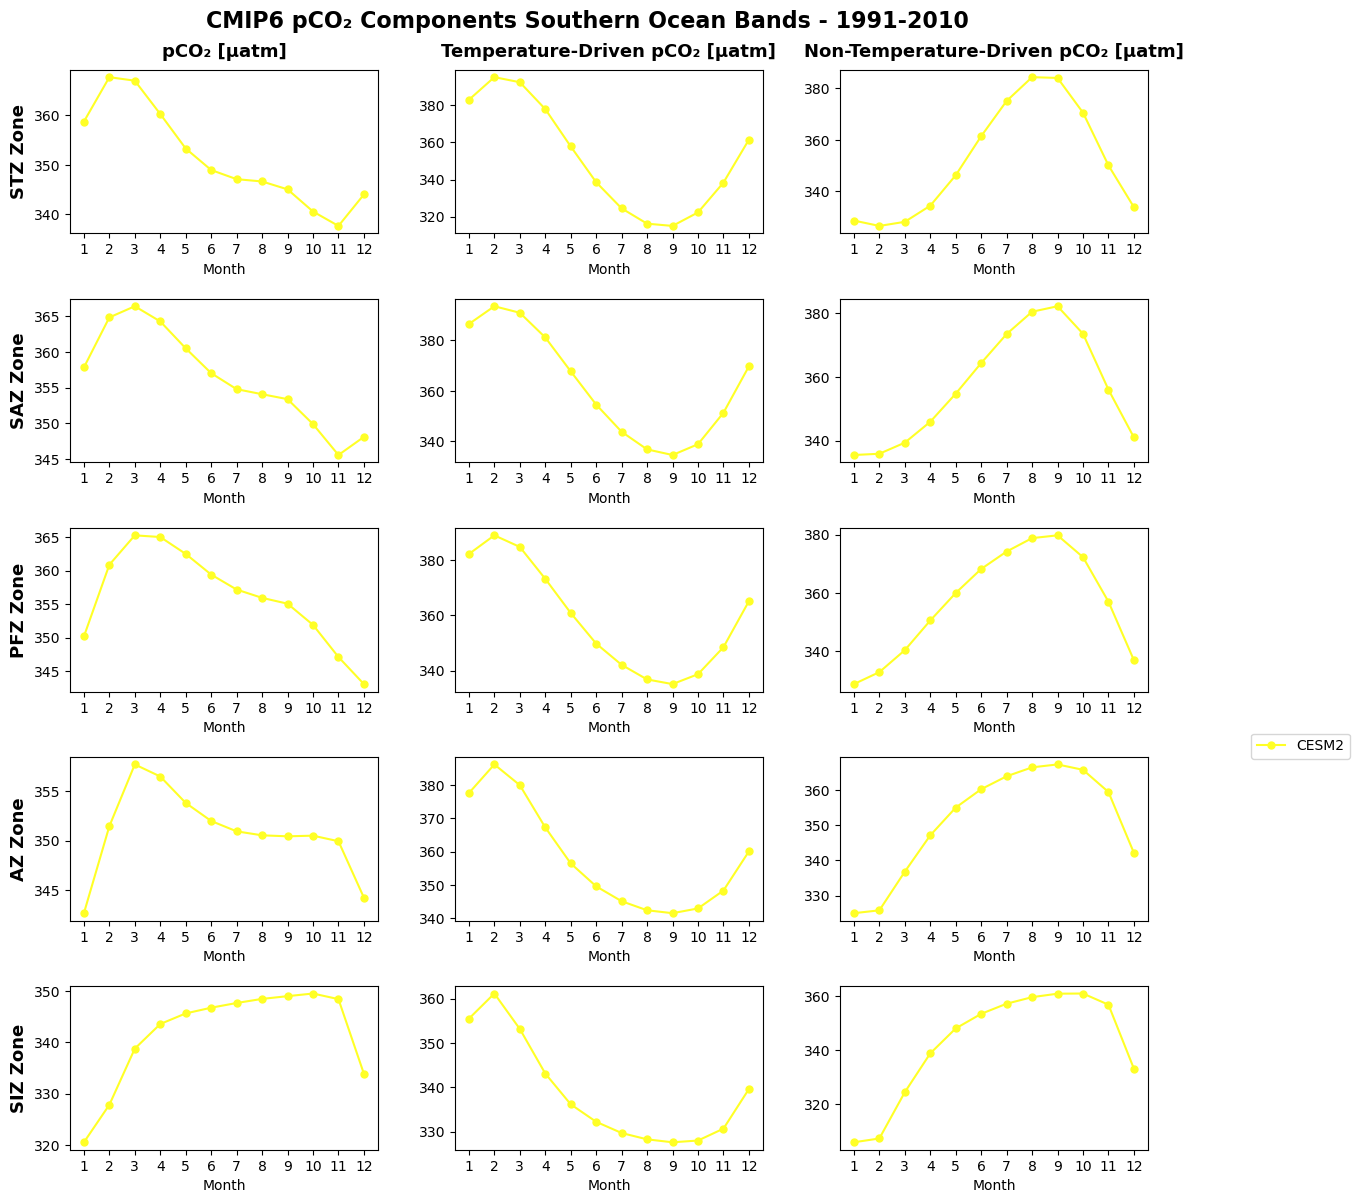

CPU times: user 1.22 s, sys: 3.6 ms, total: 1.22 s
Wall time: 1.22 s


In [18]:
%%time
regions = ['stz', 'saz', 'pfz', 'az', 'siz']
var_names = ['spco2', 'pco2-t', 'pco2-nt']  # temperature and non-temperature components
models = ['CESM2']  # add more models here as needed

plot_titles = ["pCO₂ [µatm]", "Temperature-Driven pCO₂ [µatm]", "Non-Temperature-Driven pCO₂ [µatm]"]
zone_titles = {"siz": 'SIZ Zone', "az": 'AZ Zone',
               "saz": 'SAZ Zone', "stz": 'STZ Zone', "pfz": 'PFZ Zone'}
start_year = '1991'
end_year = '2010'

fig, axes = plt.subplots(nrows=len(regions), ncols=len(var_names), figsize=(14, 12))
fig.subplots_adjust(left=0.08, bottom=0.03, right=0.85, top=0.93, hspace=0.4, wspace=0.25)

for i, region in enumerate(regions):
    for j, var in enumerate(var_names):
        ax = axes[i, j]
        for mi, model in enumerate(models):
            ofn = f'/glade/u/home/lilmi/2026ClimateBigData/testdata/{model}_{var}{start_year}{end_year}_{region}.txt'
            
            if os.path.exists(ofn):
                with open(ofn, "r") as rf:
                    dm = [float(line.strip()) for line in rf]

                
                s = np.array(dm)
                xmon = np.arange(1, 13)

                if var == "spco2": 
                    s= (s  *1000) / 101.325 #Pa -> µatm
                
                ax.plot(xmon, s, label=model, marker='o', markersize=5, color=colors[mi])
            else:
                print('Did not find:', model, var, region)
                ax.plot([], [], label=model, marker='o', markersize=5, color=colors[mi])
        
        if j == 0:
            ax.set_ylabel(zone_titles[region], fontsize=13, fontweight='bold')
        if i == 0:
            ax.set_title(plot_titles[j], fontsize=13, fontweight='bold', y=1.03)
        
        ax.ticklabel_format(axis='y', style='sci', scilimits=(-3, 1000))
        ax.set_xticks(np.arange(1, 13))
        ax.set_xlabel("Month")

fig.legend(models, loc='lower right', bbox_to_anchor=(0.999, 0.35))
plt.suptitle(f'CMIP6 pCO₂ Components Southern Ocean Bands - {start_year}-{end_year}',
             fontsize=16, weight='bold', x=0.45)
plt.show()